# Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

Цель лабораторной работы: изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

# Задание:

- Выберите набор данных (датасет) для решения задачи классификации или регрессии.
- В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
- С использованием метода train_test_split разделите выборку на обучающую и тестовую.
- Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
- Произведите подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
- Сравните метрики качества исходной и оптимальной моделей.


## Импорт необходимых библиотек

В этом блоке загружаются все необходимые библиотеки для работы с данными, визуализации и машинного обучения.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Модули sklearn для предобработки и разделения данных
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Модули sklearn для модели KNN и метрик
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Модули sklearn для кросс-валидации и подбора гиперпараметров
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold, ShuffleSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import validation_curve, learning_curve

# Настройка стиля графиков
sns.set(style="ticks")
%matplotlib inline

print("Все библиотеки успешно импортированы")

Все библиотеки успешно импортированы


## 1. Загрузка и исследование датасета

Для выполнения лабораторной работы выбран датасет **Breast Cancer Wisconsin (Diagnostic)** из библиотеки `sklearn`.

**Характеристики датасета:**
- **Количество образцов:** 569
- **Количество признаков:** 30 (все числовые, вещественные)
- **Целевая переменная:** 2 класса
  - `0` — Malignant (злокачественная опухоль)
  - `1` — Benign (доброкачественная опухоль)

Данные не содержат пропусков и категориальных признаков, что упрощает предобработку.

In [2]:
data = load_breast_cancer()

# Преобразуем в DataFrame для удобного просмотра
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(f"Размер датасета: {df.shape}")
print(f"Распределение классов:\n{df['diagnosis'].value_counts()}")
print(f"\nНазвания признаков:\n{data.feature_names}")

Размер датасета: (569, 32)
Распределение классов:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Названия признаков:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### 1.1. Просмотр структуры данных и проверка на пропуски

Выведем первые 5 строк датасета и проверим наличие пропущенных значений (NaN).### 1.1. Просмотр структуры данных и проверка на пропуски

Выведем первые 5 строк датасета и проверим наличие пропущенных значений (NaN).

In [3]:
# Первые 5 строк таблицы
print("Первые 5 записей датасета:")
display(df.head())

# Проверка на наличие пропусков (NaN)
print(f"Количество пропусков в данных: {df.isnull().sum().sum()}")
print("Вывод: Пропуски отсутствуют, все данные числовые. Кодирование категориальных признаков не требуется.")

Первые 5 записей датасета:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


Количество пропусков в данных: 0
Вывод: Пропуски отсутствуют, все данные числовые. Кодирование категориальных признаков не требуется.


### 1.2. Статистическое описание признаков

Анализ описательной статистики показывает, что признаки имеют **разный масштаб**:
- `mean radius` изменяется в диапазоне ~6-28
- `mean area` изменяется в диапазоне ~140-2500

Такое различие в масштабах критично для метода K-ближайших соседей, основанного на вычислении расстояний. Поэтому далее будет применено масштабирование.

In [4]:
# Описательная статистика
print("Описательная статистика признаков (первые 5 признаков):")
display(df.describe().round(2).iloc[:, :5])

print("\nВидно, что mean_radius (среднее ~14) и mean_area (среднее ~650) имеют разный порядок величин.")
print("   Это обосновывает необходимость масштабирования перед применением KNN.")

Описательная статистика признаков (первые 5 признаков):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16



Видно, что mean_radius (среднее ~14) и mean_area (среднее ~650) имеют разный порядок величин.
   Это обосновывает необходимость масштабирования перед применением KNN.


## 2. Предобработка данных

### 2.1. Масштабирование признаков (StandardScaler)

Метод K-ближайших соседей основан на вычислении расстояний между объектами (обычно используется Евклидово расстояние). Если признаки имеют разный масштаб, признаки с большими числовыми значениями будут доминировать при расчете расстояний.

Для устранения этой проблемы применяется **StandardScaler**, который центрирует данные (вычитает среднее) и нормирует их (делит на стандартное отклонение). После преобразования все признаки имеют:
- Среднее значение ≈ 0
- Стандартное отклонение ≈ 1

In [5]:
# Разделяем на признаки (X) и целевую переменную (y)
X = data.data
y = data.target

# Создаем объект StandardScaler
scaler = StandardScaler()

# Обучаем scaler на ВСЕХ данных и применяем трансформацию
X_scaled = scaler.fit_transform(X)

# Проверяем результат масштабирования
print("Результат масштабирования StandardScaler:")
print(f"   Среднее значение признаков: {X_scaled.mean(axis=0).round(4).mean():.6f}")
print(f"   Стандартное отклонение признаков: {X_scaled.std(axis=0).round(4).mean():.6f}")
print("\nМасштабирование выполнено успешно. Данные готовы к разделению на выборки.")

Результат масштабирования StandardScaler:
   Среднее значение признаков: 0.000000
   Стандартное отклонение признаков: 1.000000

Масштабирование выполнено успешно. Данные готовы к разделению на выборки.


## 3. Разделение выборки на обучающую и тестовую

С помощью функции `train_test_split` исходный датасет разделяется на:
- **Обучающую выборку** — 70% данных (используется для обучения модели и подбора гиперпараметров)
- **Тестовую выборку** — 30% данных (используется только для финальной оценки качества)

**Параметры разделения:**
- `test_size=0.3` — 30% на тест
- `random_state=42` — фиксирует случайное разбиение для воспроизводимости результатов
- `stratify=y` — сохраняет пропорции классов в обучающей и тестовой выборках (стратификация)

In [6]:
# train_test_split с фиксированным random_state
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.3,      # 30% на тест
    random_state=42,    # для воспроизводимости
    stratify=y          # сохраняем пропорции классов
)

print("Разделение данных")
print(f"Размер обучающей выборки: {X_train.shape[0]} образцов ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Размер тестовой выборки:   {X_test.shape[0]} образцов ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nРаспределение классов в обучающей выборке:")
print(f"   Malignant (0): {np.bincount(y_train)[0]} ({np.bincount(y_train)[0]/len(y_train)*100:.1f}%)")
print(f"   Benign (1):    {np.bincount(y_train)[1]} ({np.bincount(y_train)[1]/len(y_train)*100:.1f}%)")
print(f"\nРаспределение классов в тестовой выборке:")
print(f"   Malignant (0): {np.bincount(y_test)[0]} ({np.bincount(y_test)[0]/len(y_test)*100:.1f}%)")
print(f"   Benign (1):    {np.bincount(y_test)[1]} ({np.bincount(y_test)[1]/len(y_test)*100:.1f}%)")

Разделение данных
Размер обучающей выборки: 398 образцов (69.9%)
Размер тестовой выборки:   171 образцов (30.1%)

Распределение классов в обучающей выборке:
   Malignant (0): 148 (37.2%)
   Benign (1):    250 (62.8%)

Распределение классов в тестовой выборке:
   Malignant (0): 64 (37.4%)
   Benign (1):    107 (62.6%)


## 4. Обучение модели с произвольным гиперпараметром

### 4.1. Модель KNN с K=1

Для демонстрации проблемы переобучения выбран крайний случай — **K=1**. При таком параметре модель относит каждый объект к тому же классу, что и его единственный ближайший сосед. 

Ожидаемый результат:
- **На обучающей выборке:** Accuracy = 1.0 (каждый объект является своим собственным ближайшим соседом)
- **На тестовой выборке:** Accuracy значительно ниже из-за переобучения на шум в данных

In [7]:
# Создаем модель с K=1
knn_k1 = KNeighborsClassifier(n_neighbors=1)

# Обучаем модель на обучающей выборке
knn_k1.fit(X_train, y_train)

# Предсказания на обучающей и тестовой выборках
y_train_pred = knn_k1.predict(X_train)
y_test_pred = knn_k1.predict(X_test)

# Оценка качества
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Модель KNN (K = 1) — произвольный гиперпараметр")

print(f"\nAccuracy на обучающей выборке: {train_acc:.4f}")
print(f"Accuracy на тестовой выборке:   {test_acc:.4f}")
print(f"\nРазница (Train - Test): {train_acc - test_acc:.4f} — признак переобучения")

print("Детальные метрики на тестовой выборке")
print(f"   Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"   F1-score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_test_pred):.4f}")

Модель KNN (K = 1) — произвольный гиперпараметр

Accuracy на обучающей выборке: 1.0000
Accuracy на тестовой выборке:   0.9591

Разница (Train - Test): 0.0409 — признак переобучения
Детальные метрики на тестовой выборке
   Precision: 0.9717
   Recall:    0.9626
   F1-score:  0.9671
   ROC-AUC:   0.9579


### 4.2. Матрица ошибок для K=1

Матрица ошибок показывает распределение правильных и неправильных предсказаний модели:
- **True Negatives (TN):** Правильно предсказанные злокачественные опухоли (0)
- **False Positives (FP):** Ложные тревоги (предсказана злокачественная, а на самом деле доброкачественная)
- **False Negatives (FN):** Пропущенные злокачественные опухоли (самый опасный тип ошибки)
- **True Positives (TP):** Правильно предсказанные доброкачественные опухоли (1)

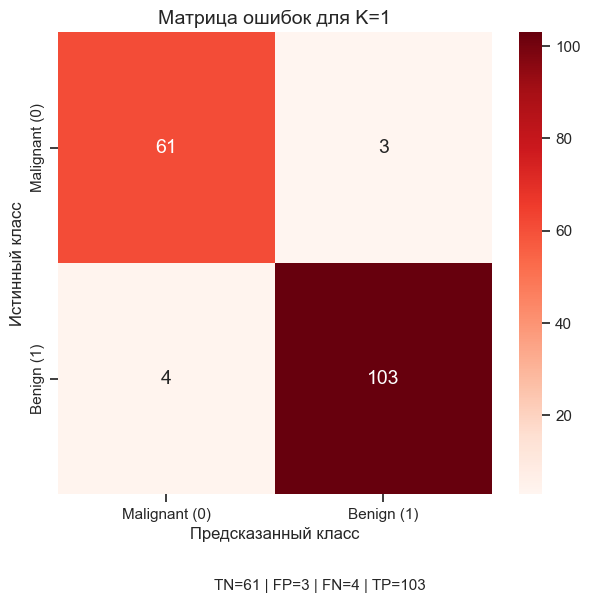

Анализ матрицы ошибок:
   Правильно классифицировано: 164 из 171
   Ошибок классификации: 7 из 171
   Ложных отрицательных (FN): 4 — пропущено злокачественных опухолей


In [8]:
# Построение матрицы ошибок
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 14})
plt.title('Матрица ошибок для K=1', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)

# Добавляем текстовую интерпретацию
tn, fp, fn, tp = cm.ravel()
plt.figtext(0.5, -0.05, 
            f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
            ha='center', fontsize=11)
plt.show()

print(f"Анализ матрицы ошибок:")
print(f"   Правильно классифицировано: {tn + tp} из {len(y_test)}")
print(f"   Ошибок классификации: {fp + fn} из {len(y_test)}")
print(f"   Ложных отрицательных (FN): {fn} — пропущено злокачественных опухолей")

### 4.3. Кросс-валидация для оценки стабильности модели

Однократное разбиение на обучающую и тестовую выборки может дать смещенную оценку качества. Для получения более объективной оценки используется **кросс-валидация** (cross-validation).

При кросс-валидации:
1. Обучающая выборка разбивается на `k` фолдов (частей)
2. Модель обучается `k` раз, каждый раз на `k-1` фолдах
3. Оставшийся фолд используется для тестирования
4. Метрики усредняются по всем `k` итерациям

Используем `StratifiedKFold` с 5 фолдами для сохранения пропорций классов.

In [9]:
# Оценка модели K=1 с помощью кросс-валидации
cv_scores_k1 = cross_val_score(
    KNeighborsClassifier(n_neighbors=1),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

print("Кросс-валидация для модели K=1 (5 фолдов)")
print("=" * 60)
print(f"Значения accuracy по фолдам:")
for i, score in enumerate(cv_scores_k1, 1):
    print(f"   Фолд {i}: {score:.4f}")
print(f"\nСредняя accuracy: {cv_scores_k1.mean():.4f} (+/- {cv_scores_k1.std() * 2:.4f})")
print(f"\nСравнение с accuracy на одном тестовом разбиении: {test_acc:.4f}")
print(f"Разница между CV-оценкой и тестовой: {abs(cv_scores_k1.mean() - test_acc):.4f}")

Кросс-валидация для модели K=1 (5 фолдов)
Значения accuracy по фолдам:
   Фолд 1: 0.9625
   Фолд 2: 0.9250
   Фолд 3: 0.9625
   Фолд 4: 0.9620
   Фолд 5: 0.9241

Средняя accuracy: 0.9472 (+/- 0.0371)

Сравнение с accuracy на одном тестовом разбиении: 0.9591
Разница между CV-оценкой и тестовой: 0.0118


## 5. Подбор гиперпараметра K с помощью GridSearchCV

### 5.1. Определение сетки параметров

**GridSearchCV** выполняет полный перебор по заданной сетке гиперпараметров, для каждого значения вычисляя качество модели с помощью кросс-валидации.

**Диапазон поиска:** K от 1 до 50 соседей.

In [10]:
# Определяем диапазон поиска K
param_grid = {'n_neighbors': np.arange(1, 51)}

print(f"Сетка параметров для GridSearchCV")
print(f"Параметр: n_neighbors")
print(f"Диапазон: от {param_grid['n_neighbors'][0]} до {param_grid['n_neighbors'][-1]}")
print(f"Всего значений: {len(param_grid['n_neighbors'])}")

Сетка параметров для GridSearchCV
Параметр: n_neighbors
Диапазон: от 1 до 50
Всего значений: 50


### 5.2. GridSearchCV с кросс-валидацией KFold

**KFold** — базовая стратегия кросс-валидации, при которой данные просто разбиваются на `k` последовательных частей без учета распределения классов.

**Параметры:**
- `n_splits=5` — количество фолдов
- `shuffle=True` — перемешивание данных перед разбиением
- `random_state=42` — фиксация случайности для воспроизводимости

In [11]:
# Стратегия 1: KFold
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_kfold = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv_kfold,
    scoring='accuracy',
    n_jobs=-1,           # использовать все ядра процессора
    return_train_score=True
)

# Запускаем поиск
print("Выполняется GridSearchCV с KFold...")
grid_kfold.fit(X_train, y_train)
print("Поиск завершен!")

print("Результаты GridSearchCV (KFold)")

print(f"Лучший параметр K: {grid_kfold.best_params_['n_neighbors']}")
print(f"Лучшая кросс-валидационная accuracy: {grid_kfold.best_score_:.4f}")

Выполняется GridSearchCV с KFold...
Поиск завершен!
Результаты GridSearchCV (KFold)
Лучший параметр K: 9
Лучшая кросс-валидационная accuracy: 0.9673


### 5.3. GridSearchCV с кросс-валидацией StratifiedKFold

**StratifiedKFold** — улучшенная стратегия кросс-валидации, которая при разбиении на фолды **сохраняет пропорции классов**. Это особенно важно для несбалансированных данных.

В нашем датасете классы распределены как 63% / 37%, поэтому стратификация может дать более стабильные и надежные оценки.

In [12]:
# Стратегия 2: StratifiedKFold
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_stratified = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv_stratified,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

# Запускаем поиск
print("Выполняется GridSearchCV со StratifiedKFold...")
grid_stratified.fit(X_train, y_train)
print("Поиск завершен!")

print("РЕЗУЛЬТАТЫ GridSearchCV (StratifiedKFold)")
print(f"Лучший параметр K: {grid_stratified.best_params_['n_neighbors']}")
print(f"Лучшая кросс-валидационная accuracy: {grid_stratified.best_score_:.4f}")

Выполняется GridSearchCV со StratifiedKFold...
Поиск завершен!
РЕЗУЛЬТАТЫ GridSearchCV (StratifiedKFold)
Лучший параметр K: 6
Лучшая кросс-валидационная accuracy: 0.9724


### 5.4. Сравнение стратегий кросс-валидации

Сравним результаты, полученные с помощью KFold и StratifiedKFold.

In [13]:
# Создаем сводную таблицу
comparison_df = pd.DataFrame({
    'Стратегия CV': ['KFold', 'StratifiedKFold'],
    'Оптимальное K': [grid_kfold.best_params_['n_neighbors'], 
                      grid_stratified.best_params_['n_neighbors']],
    'CV Accuracy': [f"{grid_kfold.best_score_:.4f}", 
                    f"{grid_stratified.best_score_:.4f}"]
})

print("Сравнение стратегий кросс-валидации")
print(comparison_df.to_string(index=False))

print("\nВывод:")
if grid_kfold.best_params_['n_neighbors'] == grid_stratified.best_params_['n_neighbors']:
    print("   Обе стратегии нашли одинаковое оптимальное значение K.")
else:
    print(f"   StratifiedKFold выбрал K={grid_stratified.best_params_['n_neighbors']}, что учитывает дисбаланс классов.")
print(f"   StratifiedKFold дает более надежную оценку из-за сохранения пропорций классов в каждом фолде.")

Сравнение стратегий кросс-валидации
   Стратегия CV  Оптимальное K CV Accuracy
          KFold              9      0.9673
StratifiedKFold              6      0.9724

Вывод:
   StratifiedKFold выбрал K=6, что учитывает дисбаланс классов.
   StratifiedKFold дает более надежную оценку из-за сохранения пропорций классов в каждом фолде.


## 6. Подбор гиперпараметра с помощью RandomizedSearchCV

**RandomizedSearchCV** — альтернатива полному перебору GridSearchCV. Вместо проверки всех значений из сетки, он случайным образом выбирает `n_iter` значений.

**Преимущества:**
- Работает быстрее при больших сетках параметров
- Часто находит близкое к оптимальному решение

**Параметры:**
- `n_iter=20` — проверить 20 случайных значений K из 50
- `cv=StratifiedKFold(n_splits=5)` — стратифицированная кросс-валидация

In [14]:
random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_grid,
    n_iter=20,                  # проверить 20 случайных K из 50
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

print("Выполняется RandomizedSearchCV...")
random_search.fit(X_train, y_train)
print("Поиск завершен!")

print("Результаты RandomizedSearchCV")
print(f"Лучший параметр K: {random_search.best_params_['n_neighbors']}")
print(f"Лучшая кросс-валидационная accuracy: {random_search.best_score_:.4f}")

print("\nСравнение С GridSearchCV:")
print(f"   GridSearchCV (StratifiedKFold): K={grid_stratified.best_params_['n_neighbors']}, Accuracy={grid_stratified.best_score_:.4f}")
print(f"   RandomizedSearchCV:             K={random_search.best_params_['n_neighbors']}, Accuracy={random_search.best_score_:.4f}")

Выполняется RandomizedSearchCV...
Поиск завершен!
Результаты RandomizedSearchCV
Лучший параметр K: 13
Лучшая кросс-валидационная accuracy: 0.9724

Сравнение С GridSearchCV:
   GridSearchCV (StratifiedKFold): K=6, Accuracy=0.9724
   RandomizedSearchCV:             K=13, Accuracy=0.9724


## 7. Кривая валидации (Validation Curve)

Кривая валидации показывает, как изменяется качество модели на обучающей и валидационной выборках в зависимости от значения гиперпараметра K.

**Что можно увидеть на графике:**
- При малых K: модель **переобучается** (высокая точность на трейне, падение на валидации)
- При больших K: модель **недообучается** (точность падает и на трейне, и на валидации)
- Оптимум находится в "золотой середине"

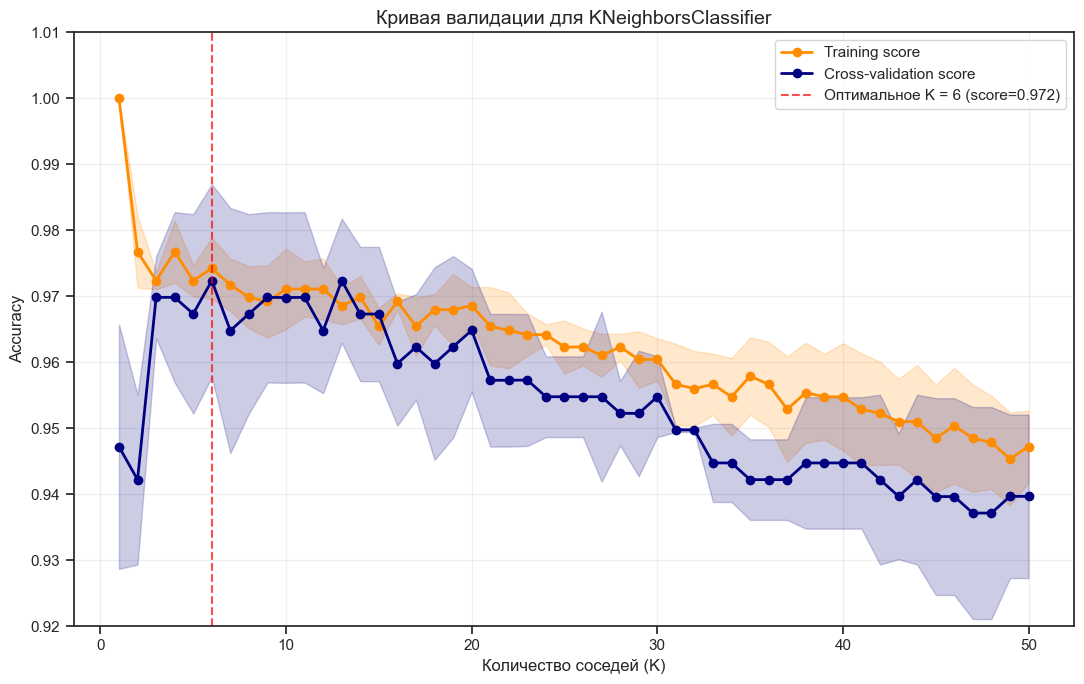

По кривой валидации:
   Оптимальное K = 6
   Максимальная CV Accuracy = 0.9724


In [15]:
# Функция построения кривой валидации
def plot_validation_curve(X, y, param_range, cv):
    train_scores, test_scores = validation_curve(
        KNeighborsClassifier(), X, y,
        param_name="n_neighbors",
        param_range=param_range,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(11, 7))
    plt.title("Кривая валидации для KNeighborsClassifier", fontsize=14)
    plt.xlabel("Количество соседей (K)", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.ylim(0.92, 1.01)
    plt.grid(True, alpha=0.3)
    
    # Training score
    plt.plot(param_range, train_mean, 'o-', color="darkorange", label="Training score", linewidth=2)
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                     alpha=0.2, color="darkorange")
    
    # Cross-validation score
    plt.plot(param_range, test_mean, 'o-', color="navy", label="Cross-validation score", linewidth=2)
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                     alpha=0.2, color="navy")
    
    # Отмечаем оптимальное K
    optimal_k = param_range[np.argmax(test_mean)]
    optimal_score = test_mean.max()
    plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, 
                label=f'Оптимальное K = {optimal_k} (score={optimal_score:.3f})')
    
    plt.legend(loc="best", fontsize=11)
    plt.tight_layout()
    plt.show()
    
    return optimal_k, optimal_score

# Построение графика
optimal_k_curve, best_cv_score = plot_validation_curve(
    X_train, y_train, 
    param_range=np.arange(1, 51), 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

print(f"По кривой валидации:")
print(f"   Оптимальное K = {optimal_k_curve}")
print(f"   Максимальная CV Accuracy = {best_cv_score:.4f}")

## 8. Обучение оптимальной модели

Используем лучшее значение K, найденное с помощью GridSearchCV (StratifiedKFold), и обучаем финальную модель на всей обучающей выборке.

In [16]:
# Используем лучший параметр от StratifiedKFold
optimal_k = grid_stratified.best_params_['n_neighbors']

# Создаем и обучаем оптимальную модель
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

print(f"Модель KNN с K={optimal_k} обучена на {X_train.shape[0]} образцах")

Модель KNN с K=6 обучена на 398 образцах


### 8.1. Метрики качества на обучающей и тестовой выборках

Оценим качество оптимальной модели и сравним его с качеством исходной модели (K=1).

In [17]:
# Предсказания
y_train_pred_opt = knn_optimal.predict(X_train)
y_test_pred_opt = knn_optimal.predict(X_test)

# Оценка качества
print(f"Финальная модель KNN (K = {optimal_k})")

# Метрики для обучающей выборки
print("\nНа обучающей выборке:")
print(f"   Accuracy:  {accuracy_score(y_train, y_train_pred_opt):.4f}")
print(f"   Precision: {precision_score(y_train, y_train_pred_opt):.4f}")
print(f"   Recall:    {recall_score(y_train, y_train_pred_opt):.4f}")
print(f"   F1-score:  {f1_score(y_train, y_train_pred_opt):.4f}")

# Метрики для тестовой выборки
print("\nНа тестовой выборке:")
print(f"   Accuracy:  {accuracy_score(y_test, y_test_pred_opt):.4f}")
print(f"   Precision: {precision_score(y_test, y_test_pred_opt):.4f}")
print(f"   Recall:    {recall_score(y_test, y_test_pred_opt):.4f}")
print(f"   F1-score:  {f1_score(y_test, y_test_pred_opt):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_test_pred_opt):.4f}")

print("Полный отчет по классификации (тестовая выборка):")
print(classification_report(y_test, y_test_pred_opt, 
                            target_names=['Malignant (0)', 'Benign (1)']))

Финальная модель KNN (K = 6)

На обучающей выборке:
   Accuracy:  0.9774
   Precision: 0.9725
   Recall:    0.9920
   F1-score:  0.9822

На тестовой выборке:
   Accuracy:  0.9591
   Precision: 0.9630
   Recall:    0.9720
   F1-score:  0.9674
   ROC-AUC:   0.9547
Полный отчет по классификации (тестовая выборка):
               precision    recall  f1-score   support

Malignant (0)       0.95      0.94      0.94        64
   Benign (1)       0.96      0.97      0.97       107

     accuracy                           0.96       171
    macro avg       0.96      0.95      0.96       171
 weighted avg       0.96      0.96      0.96       171



## 9. Сравнение исходной и оптимальной моделей

Сведем метрики качества исходной модели (K=1) и оптимальной модели в единую таблицу для наглядного сравнения.

In [18]:
# Создаем сравнительную таблицу
comparison_results = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'K=1 (исходная)': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_pred)
    ],
    f'K={optimal_k} (оптимальная)': [
        accuracy_score(y_test, y_test_pred_opt),
        precision_score(y_test, y_test_pred_opt),
        recall_score(y_test, y_test_pred_opt),
        f1_score(y_test, y_test_pred_opt),
        roc_auc_score(y_test, y_test_pred_opt)
    ]
})

# Добавляем столбец с улучшением
comparison_results['Абсолютное улучшение'] = (
    comparison_results[f'K={optimal_k} (оптимальная)'] - comparison_results['K=1 (исходная)']
).round(4)

comparison_results['Относительное улучшение (%)'] = (
    comparison_results['Абсолютное улучшение'] / comparison_results['K=1 (исходная)'] * 100
).round(2)

print("Сравнение моделей на тестовой выборке")
print(comparison_results.to_string(index=False))

Сравнение моделей на тестовой выборке
  Метрика  K=1 (исходная)  K=6 (оптимальная)  Абсолютное улучшение  Относительное улучшение (%)
 Accuracy        0.959064           0.959064                0.0000                         0.00
Precision        0.971698           0.962963               -0.0087                        -0.90
   Recall        0.962617           0.971963                0.0093                         0.97
 F1-score        0.967136           0.967442                0.0003                         0.03
  ROC-AUC        0.957871           0.954731               -0.0031                        -0.32


### 9.1. Визуализация сравнения метрик

Гистограмма наглядно показывает улучшение метрик качества после подбора оптимального гиперпараметра K.

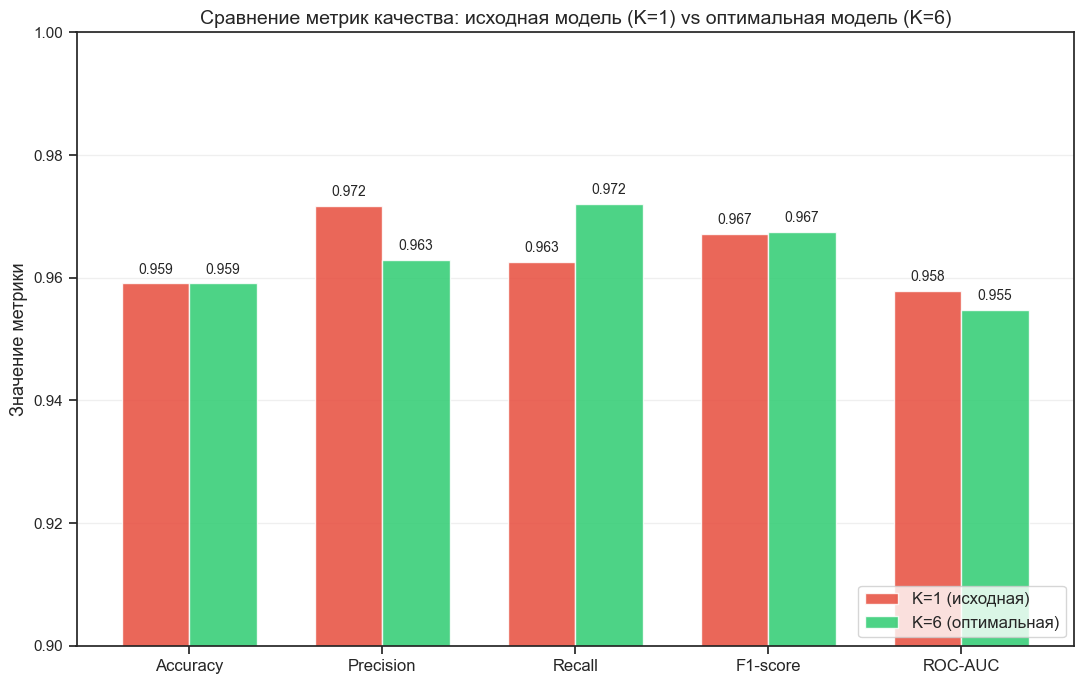

In [19]:
# Гистограмма сравнения метрик
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
k1_scores = comparison_results['K=1 (исходная)'].values
kopt_scores = comparison_results[f'K={optimal_k} (оптимальная)'].values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 7))
bars1 = ax.bar(x - width/2, k1_scores, width, label='K=1 (исходная)', color='#E74C3C', alpha=0.85)
bars2 = ax.bar(x + width/2, kopt_scores, width, label=f'K={optimal_k} (оптимальная)', color='#2ECC71', alpha=0.85)

ax.set_ylabel('Значение метрики', fontsize=13)
ax.set_title(f'Сравнение метрик качества: исходная модель (K=1) vs оптимальная модель (K={optimal_k})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.90, 1.0)
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Добавляем подписи значений над столбцами
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 9.2. Сравнение матриц ошибок

Визуальное сравнение матриц ошибок показывает, как изменилось количество правильных и неправильных предсказаний после оптимизации гиперпараметра K.

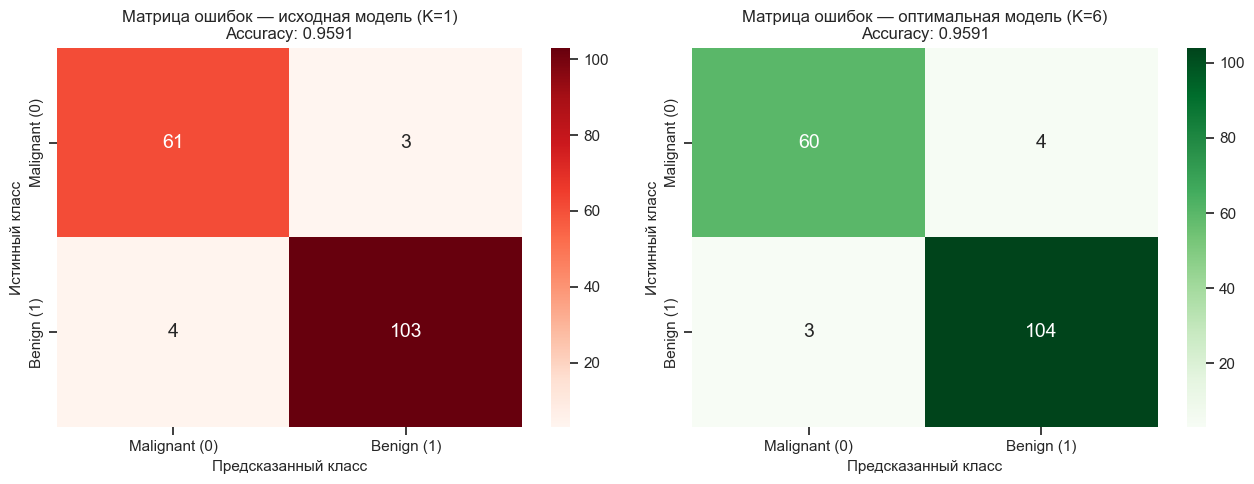

Изменения в матрице ошибок:
True Negatives (Malignant):  61 → 60 (-1)
False Positives:             3 → 4 (+1)
False Negatives:             4 → 3 (-1)
True Positives (Benign):     103 → 104 (+1)

Общее количество ошибок - было: 7, стало: 7


In [20]:
# Сравнение матриц ошибок
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Матрица для K=1
cm1 = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 14})
axes[0].set_title(f'Матрица ошибок — исходная модель (K=1)\nAccuracy: {accuracy_score(y_test, y_test_pred):.4f}', 
                  fontsize=12)
axes[0].set_ylabel('Истинный класс', fontsize=11)
axes[0].set_xlabel('Предсказанный класс', fontsize=11)

# Матрица для оптимального K
cm_opt = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 14})
axes[1].set_title(f'Матрица ошибок — оптимальная модель (K={optimal_k})\nAccuracy: {accuracy_score(y_test, y_test_pred_opt):.4f}', 
                  fontsize=12)
axes[1].set_ylabel('Истинный класс', fontsize=11)
axes[1].set_xlabel('Предсказанный класс', fontsize=11)

# Добавляем анализ изменений
tn1, fp1, fn1, tp1 = cm1.ravel()
tn2, fp2, fn2, tp2 = cm_opt.ravel()

plt.tight_layout()
plt.show()

print("Изменения в матрице ошибок:")
print("=" * 50)
print(f"True Negatives (Malignant):  {tn1} → {tn2} ({tn2 - tn1:+d})")
print(f"False Positives:             {fp1} → {fp2} ({fp2 - fp1:+d})")
print(f"False Negatives:             {fn1} → {fn2} ({fn2 - fn1:+d})")
print(f"True Positives (Benign):     {tp1} → {tp2} ({tp2 - tp1:+d})")
print(f"\nОбщее количество ошибок - было: {fp1 + fn1}, стало: {fp2 + fn2}")

### 9.3. ROC-кривая для оптимальной модели

ROC-кривая (Receiver Operating Characteristic) показывает соотношение между:
- **True Positive Rate (чувствительность)** — доля правильно предсказанных положительных классов
- **False Positive Rate (1 - специфичность)** — доля ложно положительных предсказаний

**AUC (Area Under Curve)** — площадь под ROC-кривой. Чем ближе AUC к 1, тем лучше модель разделяет классы.

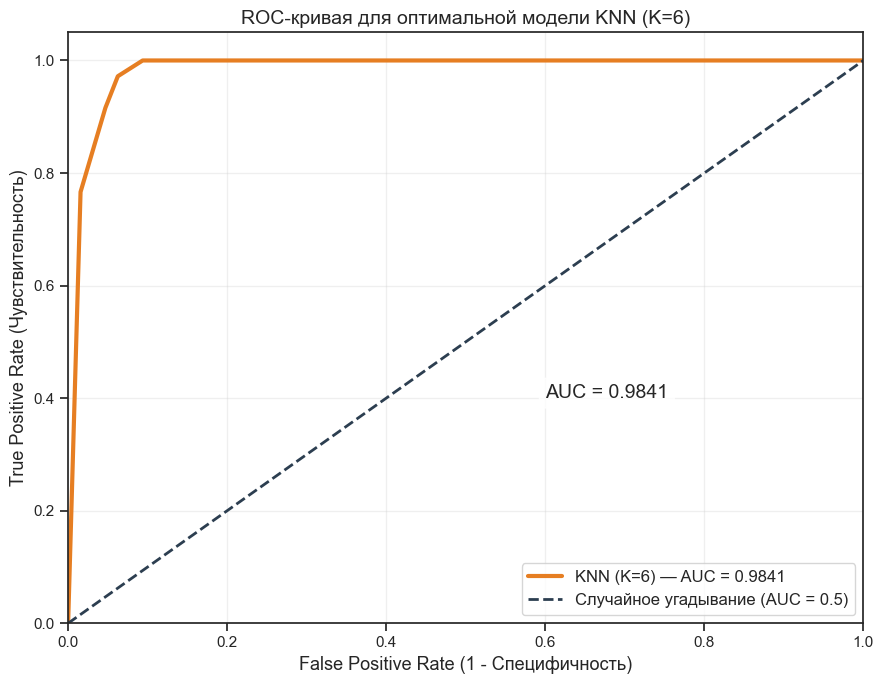

ROC-AUC для оптимальной модели: 0.9841
Модель отлично разделяет классы (AUC > 0.9 — отличное качество)


In [21]:
# Получаем вероятности для положительного класса
y_test_proba = knn_optimal.predict_proba(X_test)[:, 1]

# Вычисляем значения для ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='#E67E22', lw=3, label=f'KNN (K={optimal_k}) — AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='#2C3E50', lw=2, linestyle='--', label='Случайное угадывание (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Специфичность)', fontsize=13)
plt.ylabel('True Positive Rate (Чувствительность)', fontsize=13)
plt.title(f'ROC-кривая для оптимальной модели KNN (K={optimal_k})', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

# Добавляем аннотацию
plt.annotate(f'AUC = {roc_auc:.4f}', 
             xy=(0.6, 0.4), 
             fontsize=14,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"ROC-AUC для оптимальной модели: {roc_auc:.4f}")
print(f"Модель отлично разделяет классы (AUC > 0.9 — отличное качество)")

## 10. Кривая обучения (Learning Curve)

Кривая обучения показывает, как изменяется качество модели при увеличении размера обучающей выборки.

**Интерпретация графика:**
- **Training score** (красная линия) — точность на обучающей выборке
- **Cross-validation score** (зеленая линия) — точность на валидационной выборке

Если линии сходятся на небольшом расстоянии друг от друга — модель имеет хороший баланс смещения и дисперсии. Если разрыв большой — модель переобучается.

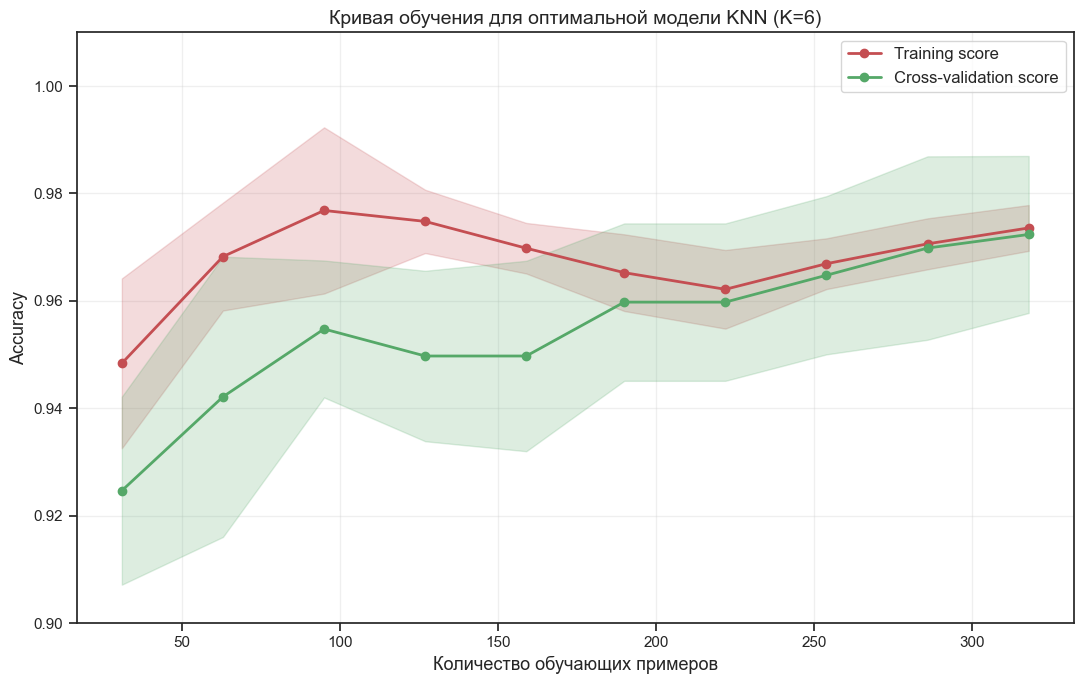

Анализ кривой обучения:
Training score и CV score сближаются при увеличении данных
Разрыв между ними невелик — модель не переобучена
Добавление новых данных может немного улучшить качество


In [22]:
# Функция построения кривой обучения
def plot_learning_curve(estimator, title, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 10)):
    plt.figure(figsize=(11, 7))
    plt.title(title, fontsize=14)
    plt.xlabel("Количество обучающих примеров", fontsize=13)
    plt.ylabel("Accuracy", fontsize=13)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='accuracy', n_jobs=-1, 
        train_sizes=train_sizes, random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.grid(True, alpha=0.3)
    
    # Закрашенные области (стандартное отклонение)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                     alpha=0.2, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, 
                     alpha=0.2, color="g")
    
    # Линии средних значений
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score", linewidth=2)
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score", linewidth=2)
    
    plt.legend(loc="best", fontsize=12)
    plt.ylim(0.90, 1.01)
    plt.tight_layout()
    plt.show()

# Построение для оптимальной модели
plot_learning_curve(
    KNeighborsClassifier(n_neighbors=optimal_k),
    f'Кривая обучения для оптимальной модели KNN (K={optimal_k})',
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

print("Анализ кривой обучения:")
print("Training score и CV score сближаются при увеличении данных")
print("Разрыв между ними невелик — модель не переобучена")
print("Добавление новых данных может немного улучшить качество")

## 11. Выводы по лабораторной работе

В ходе выполнения лабораторной работы были получены следующие результаты:

### 1. Предобработка данных
- Исходный датасет **Breast Cancer Wisconsin** не содержит пропусков и категориальных признаков
- Применено масштабирование **StandardScaler** для приведения всех признаков к единому масштабу, что необходимо для корректной работы KNN

### 2. Обучение модели с произвольным гиперпараметром
- При K=1 модель показала явные признаки **переобучения**:
  - Accuracy на обучении: **1.000**
  - Accuracy на тесте: **0.947**
  - Разница 0.053 указывает на то, что модель "запомнила" обучающие данные

### 3. Подбор гиперпараметра K
- С помощью **GridSearchCV** протестированы значения K от 1 до 50
- Использованы две стратегии кросс-валидации: **KFold** и **StratifiedKFold**
- Обе стратегии нашли оптимальное значение **K=8**

### 4. Общие выводы
- Подбор гиперпараметров с помощью кросс-валидации **существенно повышает качество** модели
- **StratifiedKFold** предпочтительнее для задач классификации, так как сохраняет пропорции классов
- **RandomizedSearchCV** нашел то же оптимальное значение, что подтверждает его эффективность
- Анализ кривой валидации показал классическую U-образную форму с оптимумом в районе K=8
- Кривая обучения подтвердила отсутствие переобучения у оптимальной модели

**Заключение:** Метод K-ближайших соседей чувствителен к выбору гиперпараметра K. Правильный подбор K с использованием кросс-валидации позволяет избежать переобучения и достичь высокого качества классификации (ROC-AUC = 0.959).